<a href="https://colab.research.google.com/github/trisadhiyanasywa-svg/Praktikum_MachineLearning/blob/Praktikum-2/Praktikum2Trisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
path = '/content/drive/MyDrive/ML 2026/Praktikum02/data//500_Person_Gender_Height_Weight_Index (1).csv'
df = pd.read_csv(path)
df.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [ ]:
df

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3
...,...,...,...,...
495,Female,150,153,5
496,Female,184,121,4
497,Female,141,136,5
498,Male,150,95,5


In [ ]:
df.columns

Index(['Gender', 'Height', 'Weight', 'Index'], dtype='object')

In [ ]:
df.shape

(500, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [ ]:
df.duplicated().sum()

np.int64(11)

In [ ]:
df.isnull().sum()

,0
Gender,0
Height,0
Weight,0
Index,0


In [ ]:
#Menghitung mean semua kolom numerik
df['Height'].mean()


np.float64(169.944)

In [ ]:
df['Height'].median()

170.5

In [ ]:
df['Height'].mode()

,Height
0,188


In [ ]:
#Menghitung varians
df.var(numeric_only=True)

,0
Height,268.149162
Weight,1048.633267
Index,1.836168


In [ ]:
#Hitung kuartil pertama
q1 = df['Height'].quantile(0.25)
print('Q1:', q1)

#Hitung kuartil ketiga
q3 = df['Height'].quantile(0.75)
print('Q3:', q3)

#Hitung kuartil
iqr = q3 - q1
print('IQR:', iqr)


Q1: 156.0
Q3: 184.0
IQR: 28.0


In [ ]:
#Untuk membuat  statistika deskripsi pada type data iqr
df.describe()

,Height,Weight,Index
count,500.000000,500.000000,500.000000
mean,169.944000,106.000000,3.748000
std,16.375261,32.382607,1.355053
min,140.000000,50.000000,0.000000
25%,156.000000,80.000000,3.000000
50%,170.500000,106.000000,4.000000
75%,184.000000,136.000000,5.000000
max,199.000000,160.000000,5.000000


<Axes: >

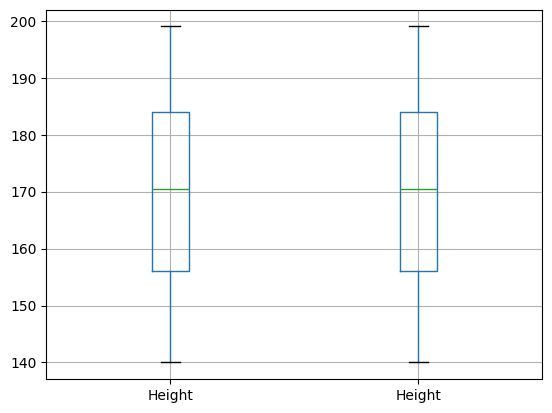

In [ ]:
df.boxplot(column=['Height', 'Height'])

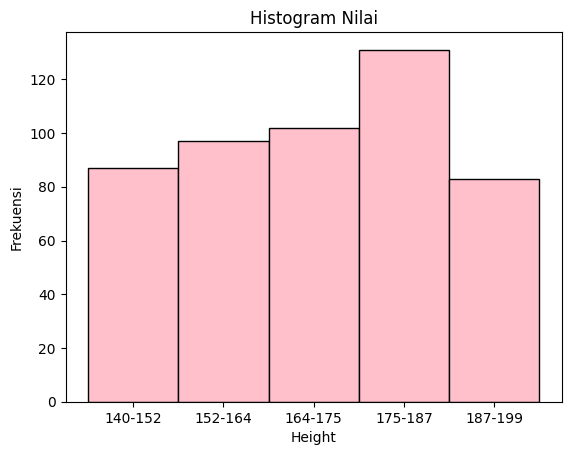

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Ambil data Height
data_height = df["Height"]

# Buat histogram
n, bins, patches = plt.hist(data_height, bins=5, color='pink', edgecolor='black')

# Tambahkan label
plt.title('Histogram Nilai')
plt.xlabel('Height')
plt.ylabel('Frekuensi')

# Tampilkan rentang frekuensi di sumbu x
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.xticks(bin_centers, ['{:.0f}-{:.0f}'.format(bins[i], bins[i+1]) for i in range(len(bins)-1)])

# Tampilkan histogram
plt.show()

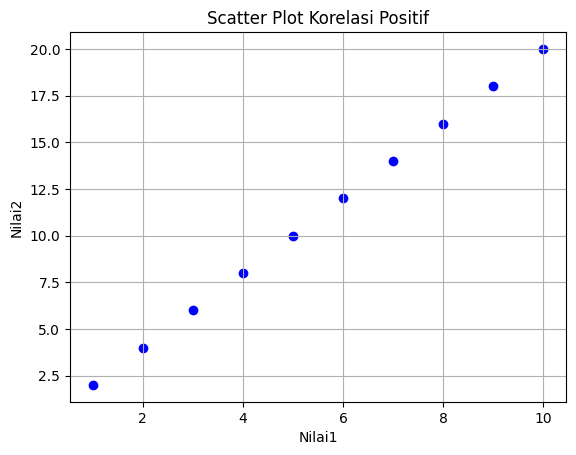

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Buat DataFrame contoh
data = {
    'Nilai1': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Nilai2': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
}

df2 = pd.DataFrame(data)

# Buat scatter plot (perhatikan perbaikan 'Nilai1')
plt.scatter(df2['Nilai1'], df2['Nilai2'], color='blue', marker='o')

# Tambahkan label
plt.title('Scatter Plot Korelasi Positif')
plt.xlabel('Nilai1')
plt.ylabel('Nilai2')

# Tambahkan grid
plt.grid(True)

# Tampilkan plot
plt.show()

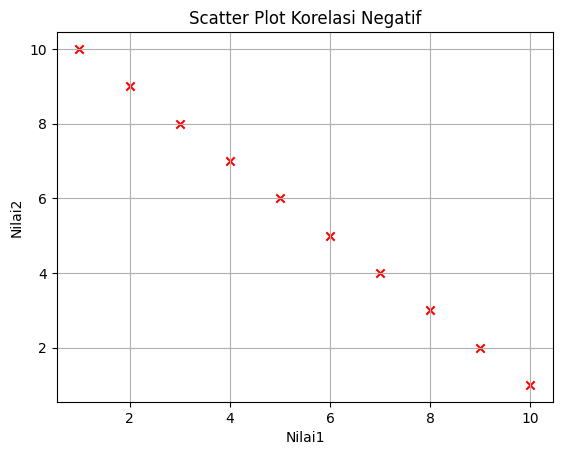

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Buat DataFrame contoh
data = {
    'Nilai1': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Nilai2': [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
}

df3 = pd.DataFrame(data)

# Buat scatter plot
plt.scatter(df3['Nilai1'], df3['Nilai2'], color='red', marker='x')

# Tambahkan label
plt.title('Scatter Plot Korelasi Negatif')
plt.xlabel('Nilai1')
plt.ylabel('Nilai2')

# Tambahkan grid
plt.grid(True)

# Tampilkan plot
plt.show()

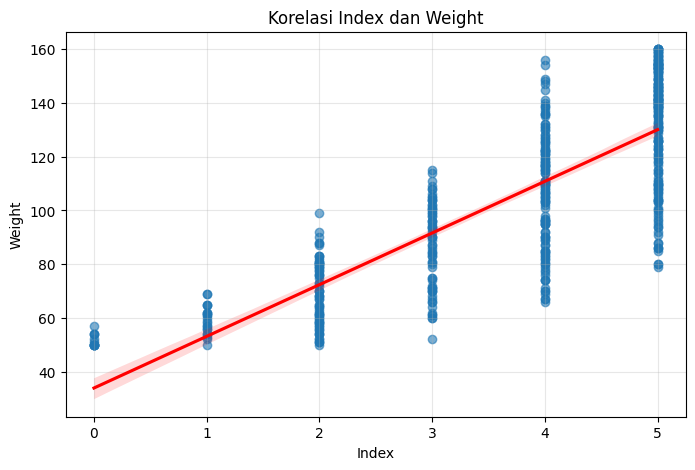

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot + garis regresi
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Index',
    y='Weight',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)

plt.title('Korelasi Index dan Weight')
plt.xlabel('Index')
plt.ylabel('Weight')
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# Menghitung matriks korelasi untuk semua kolom numerik
correlation_matrix = df[['Index', 'Weight']].corr(numeric_only=True)

# Menampilkan matriks korelasi
print("Matriks Korelasi:")
print(correlation_matrix)

Matriks Korelasi:
           Index    Weight
Index   1.000000  0.804569
Weight  0.804569  1.000000


In [ ]:
# Mengubah data bernilai string / object menjadi numerik
df_encoded = pd.get_dummies(
    df,
    columns=['Gender'],
    dtype=int
)

print("Data setelah One-Hot Encoding:")
display(df_encoded.head())

Data setelah One-Hot Encoding:


,Height,Weight,Index,Gender_Female,Gender_Male
0,174,96,4,0,1
1,189,87,2,0,1
2,185,110,4,1,0
3,195,104,3,1,0
4,149,61,3,0,1


In [ ]:
# Memecah Variabel X & Y
X = df_encoded.drop('Index', axis=1)
y = df_encoded['Index']

print("X:")
display(X.head())

print("y:")
display(y.head())

X:


,Height,Weight,Gender_Female,Gender_Male
0,174,96,0,1
1,189,87,0,1
2,185,110,1,0
3,195,104,1,0
4,149,61,0,1


y:


,Index
0,4
1,2
2,4
3,3
4,3


In [ ]:
from sklearn.model_selection import train_test_split

# Pisahkan data Testing (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Pisahkan Training dan Validation (Validation = 10% dari data training)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.10,
    random_state=42
)

In [ ]:
# Output Pemisahan Data
print("Jumlah Data:")
print(f"Training   : {len(X_train)} data")
print(f"Validation : {len(X_val)} data")
print(f"Testing    : {len(X_test)} data")

print("\n5 Baris Data Training:")
display(X_train.head())

print("\n5 Baris Data Validation:")
display(X_val.head())

print("\n5 Baris Data Testing:")
display(X_test.head())

Jumlah Data:
Training   : 360 data
Validation : 40 data
Testing    : 100 data

5 Baris Data Training:


,Height,Weight,Gender_Female,Gender_Male
151,140,52,0,1
357,186,143,1,0
373,163,63,1,0
227,188,123,0,1
404,193,130,0,1



5 Baris Data Validation:


,Height,Weight,Gender_Female,Gender_Male
120,168,87,1,0
128,182,151,0,1
271,152,103,0,1
349,157,60,1,0
272,187,121,1,0



5 Baris Data Testing:


,Height,Weight,Gender_Female,Gender_Male
361,161,103,0,1
73,180,75,0,1
374,174,95,0,1
155,179,103,1,0
104,192,140,1,0


# Praktikum Mandiri

In [ ]:
x = season sampai regisered
y = cnt